# Procesado de lenguaje natural. Fundamentos de Aprendizaje Automático: clasificación

**Pablo Martínez Olmos, Emilio Parrado Hernández, Vanessa Gómez Verdejo, Angel Navia Vázquez**

  * 1.1 (January 2026) Revised and updated version
  
Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

El **Aprendizaje Automático** (ing. "**Machine Learning, ML**") es una rama de la inteligencia artificial que persigue el **ajuste de modelos matemáticos en base a ejemplos (aprendizaje)**, es decir, sin necesidad de que éstos sean explícitamente programados para una tarea específica. Pretenden emular el proceso de aprendizaje de los seres vivos, mediante imitación, a base de prueba/error o por interacción con el entorno. Por ejemplo, un niño repitiendo palabras de sus padres para referirse a determinados objetos, aprendiendo a mantener el equilibrio, etc.

Las principales etapas del ML serían:
- Definir la **estructura del modelo**. Dicho modelo es una función matemática que dispone de una serie de valores ajustables (pesos), inicialmente aleatorios. Podemos hablar de modelos lineales, redes neuronales o redes de aprendizaje produnzo, por mencionar algunos.
- Definir la **función de coste** a minimizar, según la tarea.
- Proporcionar una **colección de ejemplos de entrenamiento** que resuelven dicha tarea.
- Definir y aplicar un **algoritmo de entrenamiento**, que permite ajustar los pesos tal que se minimice la función de coste.
- Proceder con el entrenamiento a fin de **ajustar los pesos del modelo**, hasta que el comportamiento es el deseado.
- **Medir prestaciones y reajustar** lo necesario en alguna de las etapas anteriores.

Los principales **tipos de Aprendizaje Automático** son:
- **Supervisado**: tanto las entradas al modelo como las salidas están bien definidas. Por ejemplo, un problema de clasificación en el que hay tanto datos como sus etiquetas disponibles (decidir si una opinión es positiva o negativa), o un problema de predicción donde se dispone de las magnitudes a estimar (predecir el precio de la electricidad al día siguiente).
- **No supervisado**: en este caso no hay etiquetas disponibles y se resuelve el problema atendiendo a alguna medida de bondad basada en a similitud entre las muestras. Por ejemplo, el agrupamiento es una técnica no supervisada, se organizan elementos en grupos atendiendo a algún criterio de distancia (identificar qué textos pertenecen a una misma temática). Hay también casos **semi-supervisados**, en los que se combina parte de información de etiquetas.
- **Aprendizaje por refuerzo** (ing. "**Reinforcement Learning, RL**"). El aprendizaje se consigue utilizando una señal final de refuerzo obtenida al alcanzar una meta (modelo que aprende a jugar al ajedrez en función de si pierde o gana partidas, robot que aprende a andar en función de si se cae o no).

A continuación revisaremos la formulación del modelo de **Regresión Logística** (ing. "**Logistic Regression, LR**"), un modelo lineal que se puede utilizar parar resolver problemas de clasificación supervisada y lo aplicaremos en una tarea de clasificación de textos.

<a id='reg_logistica'></a>
# 1 - Regresión Logística
---

Asumamos un problema de **clasificación binaria**, con entradas $\mathbf{x}$ y etiquetas $y\in\{0,1\}$. En **Regresión Logística (en adelante LR, ing. "Logistic Regression")** aproximamos la probabilidad de la etiqueta $y$ usando una **combinación lineal** de las entradas $\bf x$:

$$P(y=1| {\bf x}) =  \frac{1}{1+\exp(-({\bf w}^T {\bf x}+w_0))}=\sigma({\bf w}^T {\bf x}+w_0)$$


$$ P(y=0| {\bf x}) = 1- P(Y=y| {\bf x}) = 1 - \sigma({\bf w}^T {\bf x}+w_0)$$

donde

- $w_0$ y ${\bf w} = [w_1, \ldots, w_D]$ son parámetros que ajustaremos usando el conjunto de datos de entrenamiento $(\mathbf{x}^{(i)},y^{(i)})_{i=1,\ldots,N}$, es decir, siguiendo un proceso de **aprendizaje**.


- $\sigma(a) = \frac{1}{1+\exp(-a)}$ es la función **sigmoide**.

- Fijaos que la probabilidad $P(y=1| {\bf x})$ es la misma todos los puntos $\mathbf{x}$ tales que ${\bf w}^T {\bf x}$ es constante (un punto en $\mathbb{R}^1$, una recta en $\mathbb{R}^2$, un plano en $\mathbb{R}^3$, etc.).

- Además, para todo $a\in\mathbb{R}$, ${\bf w}^T {\bf x} + w_0= a$ es la ecuación de un **plano** en un espacio de dimensión D (el número de componentes de $\mathbf{x}$). Por ejemplo, una recta en el caso $D=2$.

Representemos en primer lugar la función logística $\sigma(x)$.

In [1]:
# Ejecutamos este código para preparar el contexto.
from IPython.core.display import Image, display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import cm

# Configuración de las figuras matplotlib
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

In [2]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk



In [4]:
!python --version
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1

# 2026
# Python 3.12.12
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.0
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2

Python 3.12.12
NumPy version: 2.4.2
Scipy version: 1.17.0
Pandas version: 3.0.0
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.2


In [5]:
# Cargamos las librerías necesarias de Numpy, Pandas, Scipy y Sklearn
from scipy.stats import multivariate_normal, norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from warnings import filterwarnings
filterwarnings('ignore')

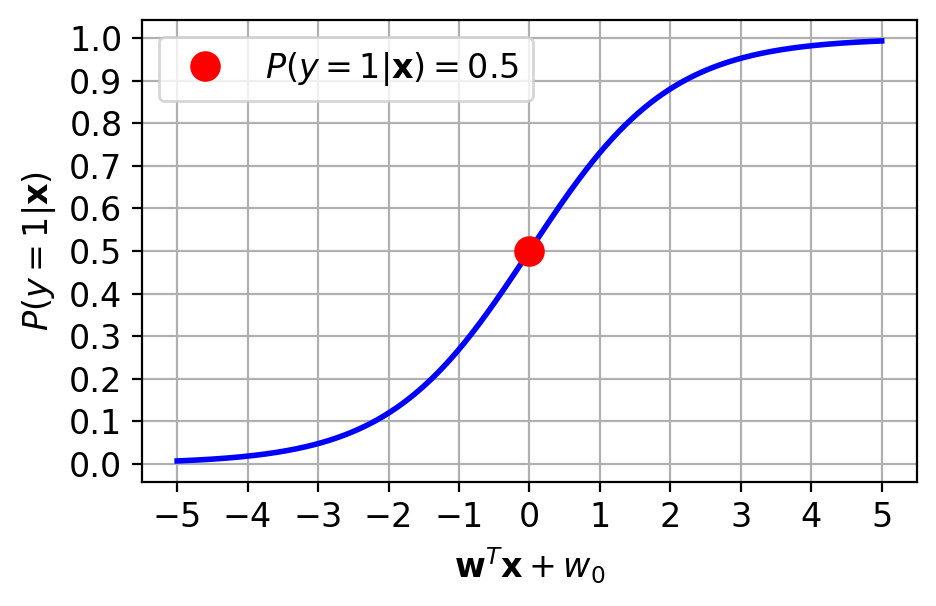

In [6]:
# Dibujamos una función sigmoide en R1
x = np.arange(-5,5,1e-3)
y = 1./(1+np.exp(-x))

fig = plt.figure(figsize=(5, 3))
plt.plot(x,y,'-b',lw=2)
plt.plot(0,0.5,'or',ms=10,label=r'$P(y=1|\mathbf{x})=0.5$')
plt.xlabel('$\mathbf{w}^T\mathbf{x}+w_0$')
plt.ylabel('$P(y=1|\mathbf{x})$')
plt.legend()
plt.xticks(np.arange(-5, 6, 1.0))
plt.grid()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()

Todos los puntos x tales que $\mathbf{w}^T\mathbf{x}+w_0=0$ forman la frontera de decisión.

Si $\mathbf{x}$ se encuentra en $\mathbb{R}^1$, la frontera de decisión en el espacio de entrada está definida únicamente por un punto.  

Si $\mathbf{x}$ se encuentra en $\mathbb{R}^2$, habrá más puntos en el espacio de entrada que cumplen $\mathbf{w}^T\mathbf{x}+w_0=0$, concretamente los puntos de la frontera estarán alineados en una recta en $\mathbb{R}^2$.

De igual forma, si $\mathbf{x}$ se encuentra en $\mathbb{R}^3$, los puntos en el espacio de entrada que cumplen $\mathbf{w}^T\mathbf{x}+w_0=0$, estarán contenidos en un plano en $\mathbb{R}^3$.

Vamos a ver ahora qué ocurre en un dataset de dos dimensiones a medida que variamos $\mathbf{w}$ y $w_0$.


In [7]:
# Cargamos los datos
from google.colab import drive
drive.mount("/content/drive")
MYDRIVE="/content/drive/MyDrive/NLP_course/"

Mounted at /content/drive


In [8]:
data_ejemplo1 = pd.read_csv(MYDRIVE + 'ejemplo1_clasificacion.txt',header=None)
data_ejemplo1.head(5)

,0,1,2
0,34.623660,78.024693,1
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [9]:
data = np.array(data_ejemplo1)

## Dimensiones
dims=np.shape(data)
N=dims[0]

## Separamos X e Y, X0 -->sin normalizar, X --> normalizadas
X0=data[:,0:2]
Y=data[:,2]

print("El conjunto de datos de entrenamiento consta de {0:d} observaciones de {1:d} dimensiones\n".format(X0.shape[0], X0.shape[1]))

print("\nObservamos que la salida toma valores binarios (0 y 1):")
print(set(Y))

El conjunto de datos de entrenamiento consta de 100 observaciones de 2 dimensiones


Observamos que la salida toma valores binarios (0 y 1):
{np.float64(0.0), np.float64(1.0)}


En ML es importante dividir los datos en entrenamiento, (validación) y test. Los datos de entrenamiento se utilizan para ajustar los parámetros libres del modelo, y los de test para evaluar prestaciones **finales**. Si se quiere realizar ajustes en el modelo en función de medidas de prestaciones, es necesario utilizar un subconjunto de los datos de entrenamiento para ello (validación), o bien utilizar técnicas tipo **N-fold cross-validation**. **Nunca se pueden elegir parámetros o hiperparámetros utilizando los resultados en test**.  

In [10]:
print("\nSeparamos los datos aleatoriamente en train y test (80%, 20%):")
# Separamos train de test, 20% para test
X0_train, X0_test, Y_train, Y_test = train_test_split(X0, Y, test_size=0.2, random_state=0)
print(X0_train.shape, Y_train.shape)
print(X0_test.shape, Y_test.shape)


Separamos los datos aleatoriamente en train y test (80%, 20%):
(80, 2) (80,)
(20, 2) (20,)


Un aspecto importante en el Aprendizaje Automático es la **normalización de los datos**. Es habitual que los datos numéricos se procesen para que cada variable tenga **media nula y desviación típica igual a 1**, lo que facilita la aplicación de muchos algoritmos de aprendizaje. Vemos qué características tienen nuestros datos y cómo podemos normalizarlos.

In [11]:
print("\n")
print("-" * 80)
print("Observamos que la media y desviación típica de X no están normalizadas:")
print("-" * 80)
print("\nMedia de cada variable (debería ser 0):")
print(np.mean(X0_train,axis=0))
print("\nDesviación típica de cada variable (debería ser 1):")
print(np.std(X0_train,axis=0))

# Normalizamos los datos (media 0, varianza 1)
normalizer = StandardScaler().fit(X0_train)

print("\n")
print("-" * 80)
print("Media y desviación típica tras normalizar:")
print("-" * 80)

X_train = normalizer.transform(X0_train)
print("\nMedia de cada variable en train (debería ser 0):")
print(np.mean(X_train,axis=0))
print("\nDesviación típica de cada variable en train (debería ser 1):")
print(np.std(X_train,axis=0))

X_test = normalizer.transform(X0_test)
print("\nMedia de cada variable en test (debería ser 0):")
print(np.mean(X_test,axis=0))
print("\nDesviación típica de cada variable en test (debería ser 1):")
print(np.std(X_test,axis=0))




--------------------------------------------------------------------------------
Observamos que la media y desviación típica de X no están normalizadas:
--------------------------------------------------------------------------------

Media de cada variable (debería ser 0):
[66.32836899 66.92937393]

Desviación típica de cada variable (debería ser 1):
[19.93793116 18.87963597]


--------------------------------------------------------------------------------
Media y desviación típica tras normalizar:
--------------------------------------------------------------------------------

Media de cada variable en train (debería ser 0):
[ 1.39194212e-15 -5.05151476e-16]

Desviación típica de cada variable en train (debería ser 1):
[1. 1.]

Media de cada variable en test (debería ser 0):
[-0.17155615 -0.18733832]

Desviación típica de cada variable en test (debería ser 1):
[0.83133938 0.8760623 ]


**¿Por qué crees que la media y desviación típica en test no son exactamente 0 y 1 respectivamente?**

Estos serían los datos sin y con normalización:

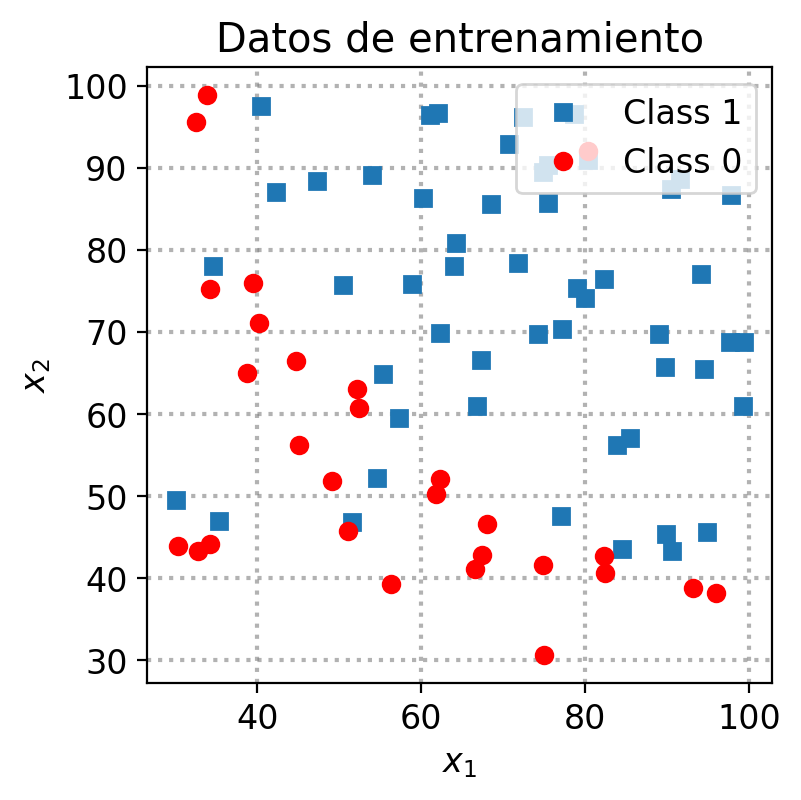

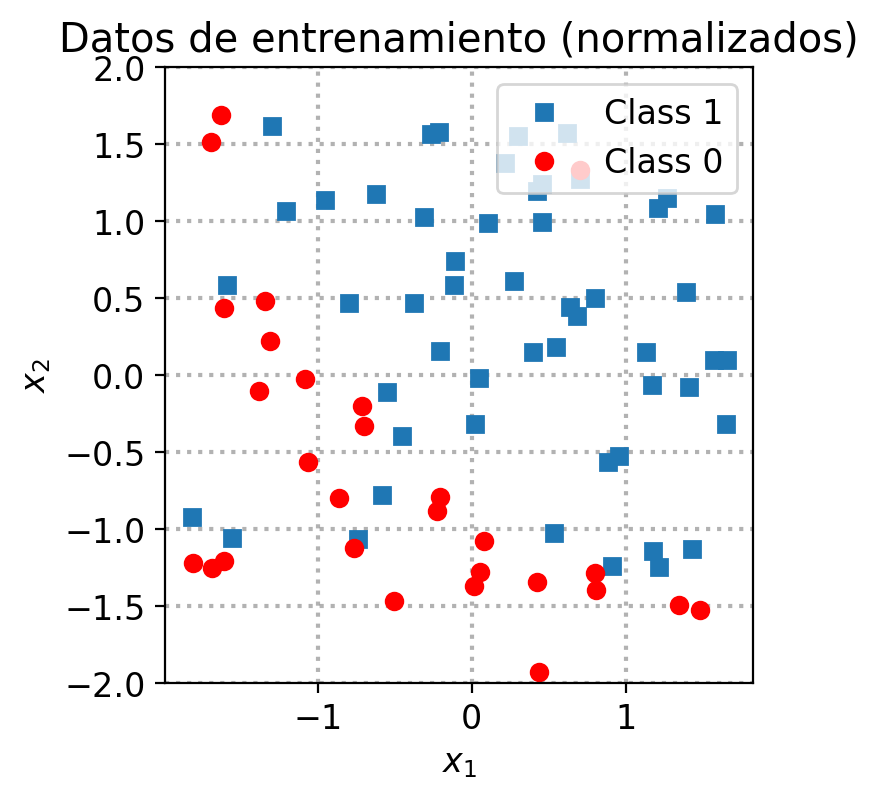

In [12]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

## Plot Training Data
index=(Y_train==1)
plt.plot(X0_train[index,0],X0_train[index,1],'s',label="Class 1")
index=(Y_train==0)
plt.plot(X0_train[index,0],X0_train[index,1],'ro',label="Class 0")
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)
plt.legend(loc='upper right')
plt.title('Datos de entrenamiento')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()


fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')
## Plot Training Data
index=(Y_train==1)
plt.plot(X_train[index,0],X_train[index,1],'s',label="Class 1")
index=(Y_train==0)
plt.plot(X_train[index,0],X_train[index,1],'ro',label="Class 0")
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.ylim([-2,2])
plt.grid(True)
plt.legend(loc='upper right')
plt.title('Datos de entrenamiento (normalizados)')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()




Con el siguiente código representamos las **curvas de nivel de igual probabilidad** estimadas por RL para distintos vectores $\mathbf{w}$ (fijando $w_0=0$):

Cada línea representa puntos del plano (x_1,x_2) con igual probabilidad P(y=1|x)


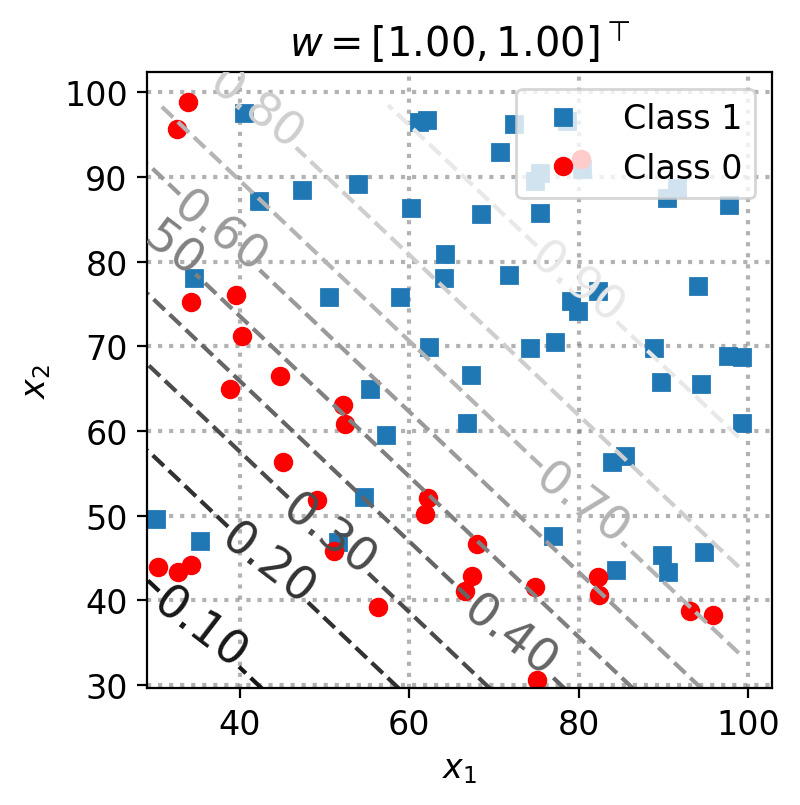

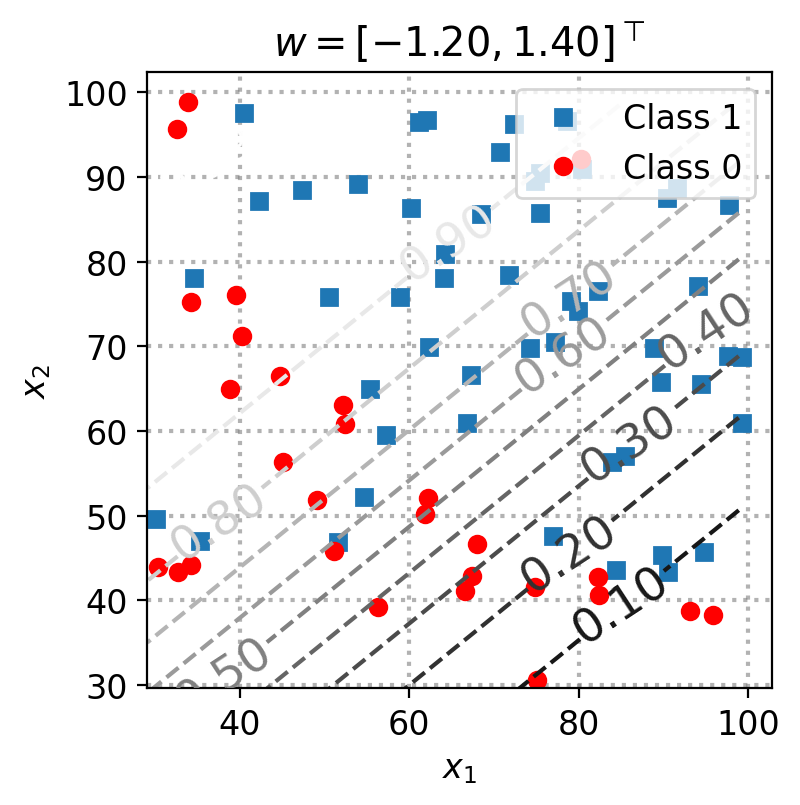

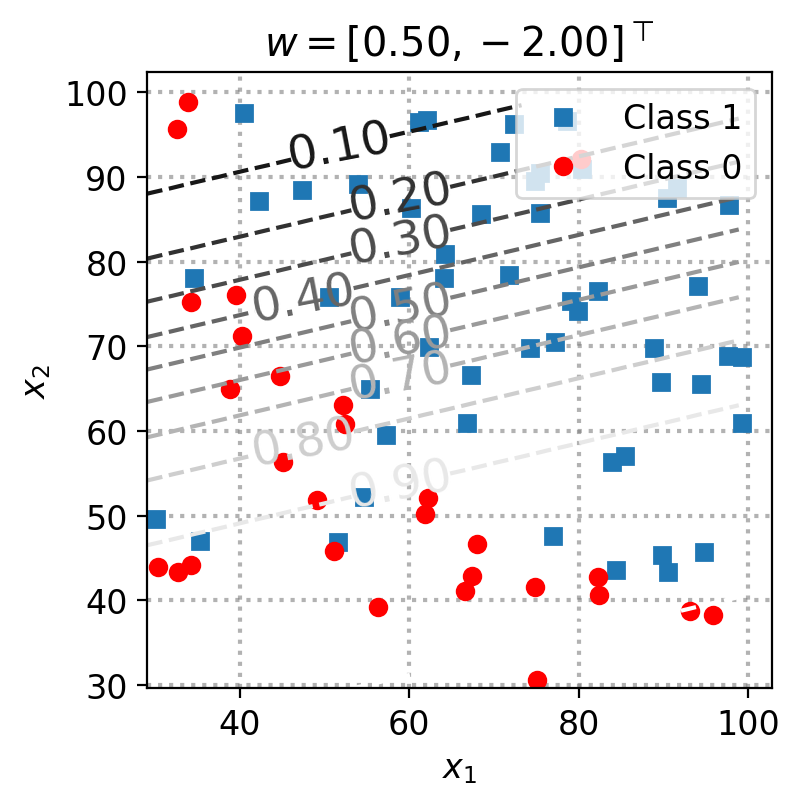

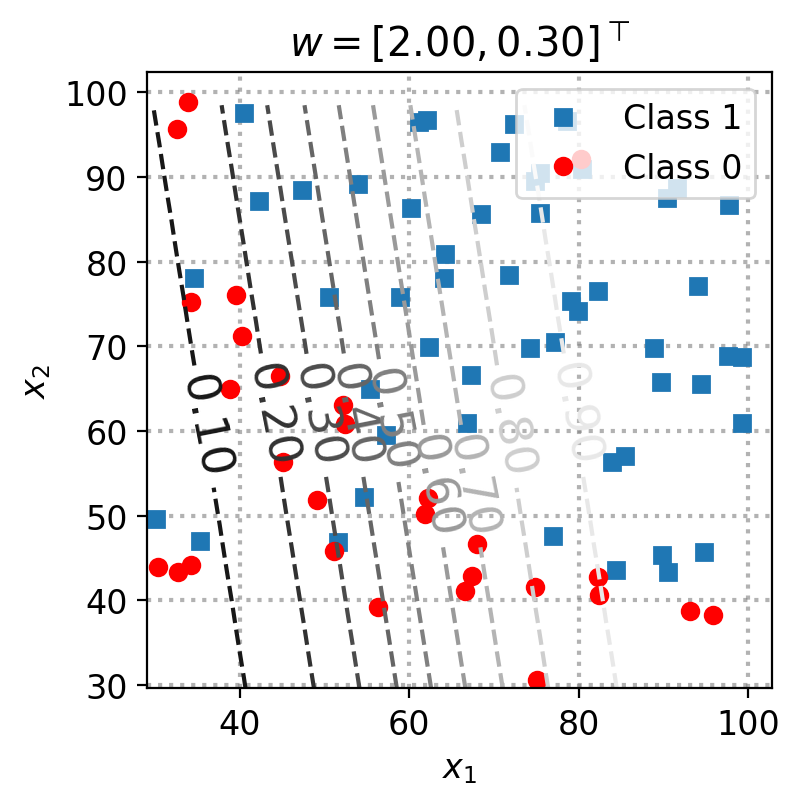

In [13]:
# Posibles vectores de parámetros
v_w = np.array([[1,1],
                [-1.2,1.4],
                [0.5,-2],
                [2,.3]])

w0 = 0.97

n_w = v_w.shape[0]

# Obtenemos una rejilla de puntos en los que evaluaremos nuestro RL
# LA REJILLA SE DEFINE EN EL ESPACIO ORIGINAL DE LOS DATOS (ANTES DE NORMALIZAR)

# Variables para la representación de la frontera de decisión (antes de normalizar!)
min1=np.min(X0_train[:,0])-1
max1=np.max(X0_train[:,0])+1
min2=np.min(X0_train[:,1])-1
max2=np.max(X0_train[:,1])+1

x1,x2 = np.mgrid[min1:max1:(max1-min1)/50, min2:max2:(max2-min2)/50]
grid = np.transpose(np.row_stack([x1.ravel(), x2.ravel()]))
# Normalizamos la rejilla
grid_norm = normalizer.transform(grid)

values = [0.01] + list(np.arange(0.1,1,0.1)) + [0.99]

print(r"Cada línea representa puntos del plano (x_1,x_2) con igual probabilidad P(y=1|x)")

for iw in range(n_w):
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot()
    ax.set_aspect('equal', adjustable='box')

    w = v_w[iw,:]
    # Calculamos P(Y=1|X) para todos los puntos de la rejilla
    zgrid = 1./(1+np.exp(-grid_norm.dot(w)-w0))
    index=(Y_train==1)
    ax.plot(X0_train[index,0],X0_train[index,1],'s',label="Class 1")
    index=(Y_train==0)
    ax.plot(X0_train[index,0],X0_train[index,1],'ro',label="Class 0")
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
    ax.set_title("$w=[{0:.2f}, {1:.2f}]^\\top$".format(w[0],w[1]))
    CS = ax.contour(x1,x2,np.reshape(zgrid,np.shape(x1)),values,cmap=cm.gray,linestyles='dashed')
    ax.clabel(CS, inline=1, fontsize=17)
    ax.legend(loc='upper right')


Vemos que diferentes pesos o parámetros del modelo producen **diferentes soluciones**. Si el objetivo es "separar las muestras rojas de las azules" parece obvio que **algunos de los pesos indicados están mejor orientados que otros**. Veamos un **criterio objetivo** para definir la **calidad de las soluciones**, y últimamente para definir un **algoritmo de entrenamiento** que permita ajustar dichos pesos de forma **óptima**.

## 1.1 - Función de coste en Regresión Logística
---
 En el caso de la Regresión logística se define la siguiente función de coste, denominada "**Log Loss**", que mide la bondad de cada uno de los posibles pesos ${\bf w}$ (${w}_0$ se considera incluido dentro de ${\bf w}$):

$$l({\bf w}) = -\sum_{i=1}^N \left\lbrace  y^{(i)}\log \left(  P(Y=1| {\bf x}^{(i)})\right)  + (1-y^{(i)}) \log\left(  1- P(Y=1| {\bf x}^{(i)}) \right)  \right\rbrace $$

Este coste también se conoce como **entropía cruzada** (ing. "cross-entropy"). El concepto de "entropía de la información" se remonta al año 1948 y fue introducido por Claude Shannon en el contexto de la Teoría de la Información. Mide básicamente el **desorden de un sistema o la incertidumbre de una variable aleatoria**. Como vemos, no sólo es función de los propios pesos del modelo, sino que se calcula promediando sobre el **conjunto de N datos disponibles para el entrenamiento**, combinando tanto las etiquetas correctas como las estimaciones de probabilidad en función de los datos de entrada.


Observemos que $l({\bf w})$ comprende dos términos: nótese que el primero sólo contribuye al coste cuando $y^{(i)} = 1$, y el segundo cuando $y^{(i)} = 0$. Observe en la siguiente figura la representación de cada uno de esos dos términos que compone la entropía cruzada. Para el caso de las muestras con etiqueta $y^{(i)} = 1$, se alcanza el mínimo cuando $P(Y=1| {\bf x})$ se acerca a 1, y en el caso de las muestras con etiqueta $y^{(i)} = 0$, se alcanza el mínimo cuando $P(Y=1| {\bf x})$ se acerca a 0.

<center>
<img src="http://www.tsc.uc3m.es/~navia/figures/XE_cost.png" width="40%">
</center>

Para seleccionar el mejor vector $\mathbf{w}$, LR minimiza la entropía cruzada, resolviendo el siguiente problema de optimización:


$${\bf w}^* =\displaystyle \underset{{\bf w}}{\operatorname{min}} l({\bf w})$$



- Se puede interpretar como el intento de alinear los **valores estimados de probabilidad** con las **etiquetas reales**, mediante el ajuste de los parámetros libres $\mathbf{w}$ y $w_0$.



- Este problema no tiene solución cerrada. Se resuelve con **optimización numérica**.


A continuación, entrenaremos un modelo de Regresión Logística con los parámetros por defecto en sklearn (luego hablaremos del entrenamiento en sí  y qué hiperparámetros nos ofrece la [implementación de sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)).

In [14]:
from sklearn.linear_model import LogisticRegression as LR

# Definimos el modelo de Regresión Logística:
mi_LR1 = LR()

# Entrenamos el modelo
mi_LR1.fit(X_train,Y_train)

LogisticRegression()

Los pesos del modelo entrenado son los siguientes

In [15]:
print("El vector w es")
print(mi_LR1.coef_)
print("Y el bias w0 es")
print(mi_LR1.intercept_)

El vector w es
[[1.02734924 1.20103904]]
Y el bias w0 es
[0.89603065]


Dibujemos primero la frontera de decisión $P(y=1|\mathbf{x})=0.5$

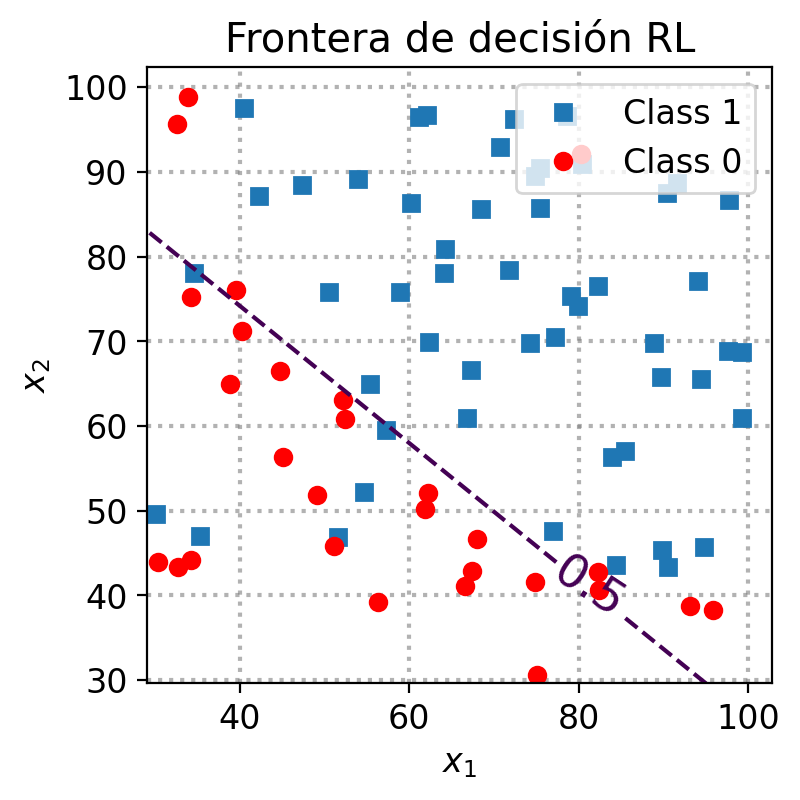

In [16]:
#Estimamos la probabilidad asociada a cada punto con el método .predic_proba
probs_LR1=mi_LR1.predict_proba(grid_norm)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

## Plot Training Data
plt.plot(X0_train[Y_train==1,0],X0_train[Y_train==1,1],'s',label="Class 1")
plt.plot(X0_train[Y_train==0,0],X0_train[Y_train==0,1],'ro',label="Class 0")
cs = ax.contour(x1,x2,np.reshape(probs_LR1[:,1],np.shape(x1)),[0.5],linestyles='dashed')
ax.clabel(cs, inline=1, fontsize=17)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='upper right')
plt.title(r'Frontera de decisión RL')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()

Y a continuación el mapa de probabilidades final ...

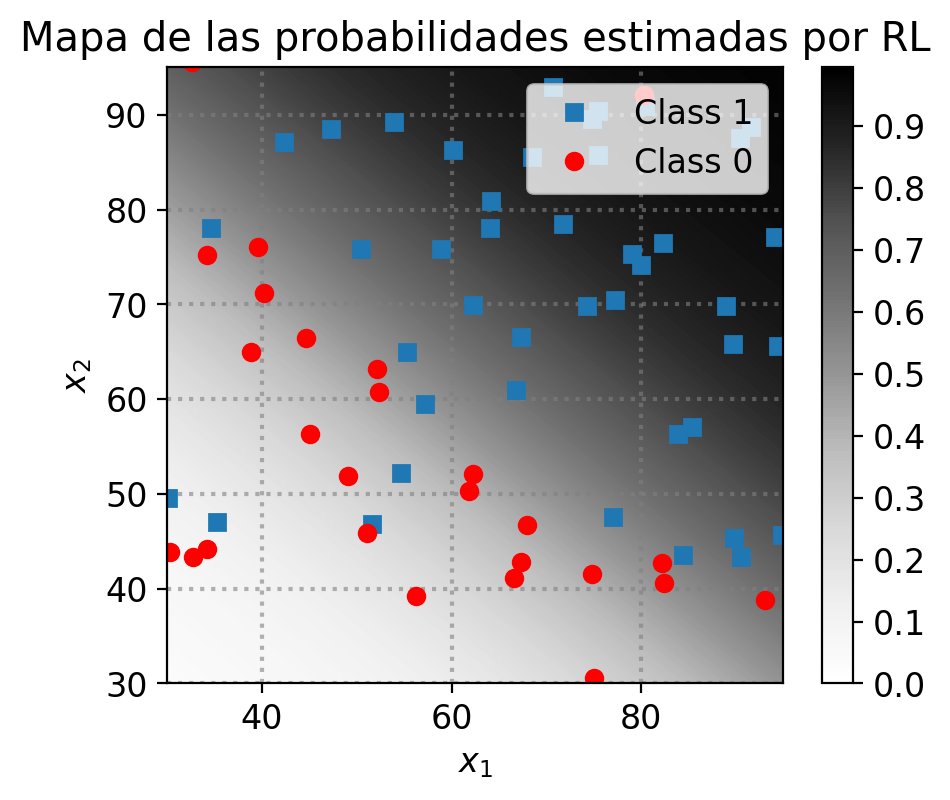

In [17]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

## Plot Training Data
plt.plot(X0_train[Y_train==1,0],X0_train[Y_train==1,1],'s',label="Class 1")
plt.plot(X0_train[Y_train==0,0],X0_train[Y_train==0,1],'ro',label="Class 0")
cs = ax.contourf(x1,x2,np.reshape(probs_LR1[:,1],np.shape(x1)),np.arange(0,1,0.005),linestyles='dashed',cmap='Greys')
cbar = fig.colorbar(cs)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='upper right')
plt.xlim([30,95])
plt.ylim([30,95])
plt.title('Mapa de las probabilidades estimadas por RL')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()

In [18]:
# Score de clasificación en train/test
accuracy_train = mi_LR1.score(X_train,Y_train)
accuracy_test = mi_LR1.score(X_test,Y_test)

print("Accuracy train {0:.2f}%. Accuracy test {1:.2f}%\n".format(accuracy_train*100, accuracy_test*100))


Accuracy train 82.50%. Accuracy test 95.00%



## 1.2 - Regularización en Regresión Logística
---

En ocasiones, los modelos de ML pueden **sobreajustar**, esto es ajustarse demasiado a los datos de entrenamiento y empeorar significativamente en test. Para evitarlo, podemos penalizar la magnitud de los pesos añadiendo un término de **regularización**, concretamente en la función de coste del Regresor Logístico:


* **Regularización cuadrática ($L_2$)**:

$$ \bf w^* = \displaystyle \underset{{\bf w}}{\operatorname{min}} \{l({\bf w}) + \frac{1}{C} \Vert {\bf w} \Vert_2^2 \}$$

* **Regularización absoluta ($L_1$)**:

$$ \bf w^* = \displaystyle \underset{{\bf w}}{\operatorname{min}} \{ l({\bf w}) + \frac{1}{C} \Vert {\bf w} \Vert_1 \}$$

donde $l({\bf w})$ es la función de coste de LR que vimos anteriormente. El término de regularización cuadrática ($\frac{1}{C} \Vert {\bf w} \Vert_2^2$) consigue una **regularización más uniforme a lo largo de todos los pesos** (y algo mejor de precisión de clasificación ya que tiene más grados de libertad), mientras que con la regularización absoluta ($\frac{1}{C} \Vert {\bf w} \Vert_1 $) la **solución tiende a ser dispersa**, muchos pesos se van a cero y esto nos permite determinar qué características de entrada son más relevantes para el modelo.

El parámetro $C$ mide la "fuerza" con la que se aplica esa regularización. Para valores muy pequeños de $C$, el peso del término de regularización aumenta, y tomar un valor $C = \infty$ equivale a no utilizar regularización.

La [implementación de LR en sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) nos permite selccionar de forma sencilla el tipo de regularización y el parámetro $C$. Este parámetro lo escogeremos por validación cruzada usando [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).


## 1.3 - Una base de datos real: spam detection
- **4601 observaciones** (1813 son spam, 39.4%)
- **target binario**: spam ($y=1$) o no spam ($y=0$)
- No disponemos directamente de los textos, las observaciones están formadas por **57 variables continuas** obtenidas tras un procesado del lenguaje:
  - 48 variables reales continuas en el intervalo [0,100] *word_freq_WORD*: **frecuencia de aparición de la palabra** *WORD* en el correo (en porcentaje)
  - 6 variables reales continuas en el intervalo [0,100] *char_freq_CHAR*: **frecuencia de aparición del caracter** *CHAR* en el correo (porcentaje)
  - 1 variable real continua: **longitud promedio de secuencias de caracteres en mayúscula ininterrumpidos**
  - 1 variable entera continua: **longitud de la secuencia de mayúsculas ininterrumpida más larga**
  - 1 variable entera continua: **número total de mayúsculas en el correo**

  En la base de datos no se indica el motivo de la elección de estas medidas, pero han debido ser fruto de una **selección de características** más adecuadas a este problema.
  

In [19]:
def load_spam():
    data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data',header=None)
    data.columns=["wf_make",
        "wf_address",
        "wf_all",
        "wf_3d",
        "wf_our",
        "wf_over",
        "wf_remove",
        "wf_internet",
        "wf_order",
        "wf_mail",
        "wf_receive",
        "wf_will",
        "wf_people",
        "wf_report",
        "wf_addresses",
        "wf_free",
        "wf_business",
        "wf_email",
        "wf_you",
        "wf_credit",
        "wf_your",
        "wf_font",
        "wf_000",
        "wf_money",
        "wf_hp",
        "wf_hpl",
        "wf_george",
        "wf_650",
        "wf_lab",
        "wf_labs",
        "wf_telnet",
        "wf_857",
        "wf_data",
        "wf_415",
        "wf_85",
        "wf_technology",
        "wf_1999",
        "wf_parts",
        "wf_pm",
        "wf_direct",
        "wf_cs",
        "wf_meeting",
        "wf_original",
        "wf_project",
        "wf_re",
        "wf_edu",
        "wf_table",
        "wf_conference",
        "cf_;",
        "cf_(",
        "cf_[",
        "cf_!",
        "cf_$",
        "cf_#",
        "cap_average",
        "cap_longest",
        "cap_total",
        "target"]
    return data

In [20]:
data = load_spam()
X0_spam = data[data.columns[:57]].values
Y_spam = data['target'].values

print("Cargadas {0:d} observaciones con {1:d} columnas\n".format(len(data), len(data.columns)))
print("Ejemplos")
data.head()


Cargadas 4601 observaciones con 58 columnas

Ejemplos


,wf_make,wf_address,wf_all,wf_3d,wf_our,wf_over,wf_remove,wf_internet,wf_order,wf_mail,...,cf_;,cf_(,cf_[,cf_!,cf_$,cf_#,cap_average,cap_longest,cap_total,target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


**Dividimos la base de datos en train (70%) y test (30%) y normalizamos**

In [21]:
# Dividimos train/test.
X0_spam_train, X0_spam_test, Y_spam_train, Y_spam_test = train_test_split(
    X0_spam, Y_spam, test_size=0.3, random_state=42)

print(X0_spam_train.shape, Y_spam_train.shape)
print(X0_spam_test.shape, Y_spam_test.shape)

# X0--> Datos originales, X --> Normalizados
transformer_spam = StandardScaler().fit(X0_spam_train)
X_spam_train = transformer_spam.transform(X0_spam_train)
X_spam_test = transformer_spam.transform(X0_spam_test)

(3220, 57) (3220,)
(1381, 57) (1381,)


Ahora vamos a utilizar **validación cruzada N-fold (GridSearchCV)** para elegir los mejores hiperparámetros (**C**, en este caso):

In [22]:
""" Ajusto C por validación cruzada
El optimizador por defecto ('lbfgs') no acepta regularización l1.
Usamos 'liblinear' siguiendo las recomendaciones de la librería.
"""

from sklearn.model_selection import GridSearchCV

# Rango C en escala logarítmica (base 10). Esto es, 20 puntos desde 10^3, a 10^3.
rango_C = np.logspace(-3, 3, 10)

diccionario_parametros = [{'C': rango_C}]
nfold = 10 # Número de particiones train/validación

LR_spam  = GridSearchCV(estimator=LR(penalty='l2'), param_grid=diccionario_parametros, cv=nfold)

# Entrenar el modelo
LR_spam.fit(X_spam_train,Y_spam_train)

# Identificamos el mejor valor para C:
print("El mejor parámetro C es {0:.2f}".format(LR_spam.best_params_['C']))

# Score de clasificación en train/test
accuracy_train = LR_spam.score(X_spam_train,Y_spam_train)
accuracy_test = LR_spam.score(X_spam_test,Y_spam_test)

print("Accuracy train {0:.2f}%. Accuracy test {1:.2f}%\n".format(accuracy_train*100, accuracy_test*100))


El mejor parámetro C es 0.10
Accuracy train 92.52%. Accuracy test 91.60%



Dibujemos los pesos del clasificador, como medida de la importancia de cada variable. El **modelo entrenado para el mejor valor de C** se encuentra en **LR_spam.best_estimator_**.

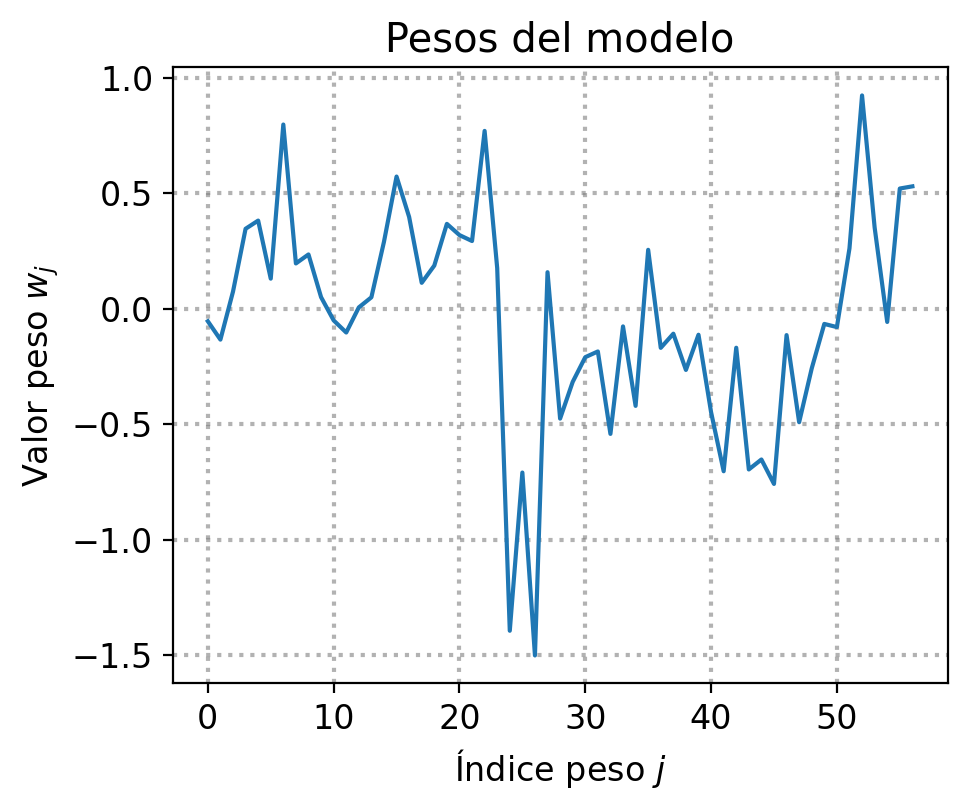

In [23]:
fig = plt.figure(figsize=(5, 4))

pesos = LR_spam.best_estimator_.coef_.T
plt.plot(pesos)
plt.xlabel(r'Índice peso $j$')
plt.ylabel(r'Valor peso $w_j$')
plt.title(r'Pesos del modelo')
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

plt.show()



### Ejercicio

Identifique los pesos positivos y negativos e indique qué características contribuyen positivamente o negativamente a la detección del spam.

In [ ]:
print("Pesos de la aparición de las palabras:")
pesos_palabras = <INSERT CODE HERE>
pesos_caracteres = <INSERT CODE HERE>
pesos_cadenas = <INSERT CODE HERE>

# palabras a contar
palabras = <INSERT CODE HERE>
# caracteres a contar
caracteres = <INSERT CODE HERE>

palabras_positivas = <INSERT CODE HERE>
palabras_negativas = <INSERT CODE HERE>
caracteres_positivos = <INSERT CODE HERE>
caracteres_negativos = <INSERT CODE HERE>

print("\nPalabras positivas:")
print(palabras_positivas)

print("\nPalabras negativas:")
print(palabras_negativas)

print("\nCaracteres positivos:")
print(caracteres_positivos)

print("\nCaracteres negativos:")
print(caracteres_negativos)

print("\nPesos de las cadenas:")
print(pesos_cadenas)

### Solucion

In [24]:
print("Pesos de la aparición de las palabras:")
pesos_palabras = pesos[0:48].ravel()
pesos_caracteres = pesos[48:54].ravel()
pesos_cadenas = pesos[54:].ravel()

# palabras a contar
palabras = [word[3:] for word in list(data.columns) if word[0:3] == 'wf_']
# caracteres a contar
caracteres = [word[3:] for word in list(data.columns) if word[0:3] == 'cf_']

palabras_positivas = []
palabras_negativas = []
for k in range(len(palabras)):
  if pesos_palabras[k] > 0:
    palabras_positivas.append(palabras[k])
  else:
    palabras_negativas.append(palabras[k])

caracteres_positivos = []
caracteres_negativos = []
for k in range(len(caracteres)):
  if pesos_caracteres[k] > 0:
    caracteres_positivos.append(caracteres[k])
  else:
    caracteres_negativos.append(caracteres[k])

print("\nPalabras positivas:")
print(palabras_positivas)

print("\nPalabras negativas:")
print(palabras_negativas)

print("\nCaracteres positivos:")
print(caracteres_positivos)

print("\nCaracteres negativos:")
print(caracteres_negativos)

print("\nPesos de las cadenas:")
print(pesos_cadenas)

Pesos de la aparición de las palabras:

Palabras positivas:
['all', '3d', 'our', 'over', 'remove', 'internet', 'order', 'mail', 'people', 'report', 'addresses', 'free', 'business', 'email', 'you', 'credit', 'your', 'font', '000', 'money', '650', 'technology']

Palabras negativas:
['make', 'address', 'receive', 'will', 'hp', 'hpl', 'george', 'lab', 'labs', 'telnet', '857', 'data', '415', '85', '1999', 'parts', 'pm', 'direct', 'cs', 'meeting', 'original', 'project', 're', 'edu', 'table', 'conference']

Caracteres positivos:
['!', '$', '#']

Caracteres negativos:
[';', '(', '[']

Pesos de las cadenas:
[-0.05801142  0.51957085  0.52902517]


# 2 - Clasificación k-NN

Un k-NN es una alternativa **no paramétrica** a LR (la complejidad depende de la disposición de los datos). El planteamiento del clasificador K-NN es muy sencillo, buscamos los **vecinos más cercanos** y **asignamos por mayoría la etiqueta ganadora**. Dado un nuevo punto $\mathbf{x}^*$, el objetivo estimado $y^*$ se calcula de la siguiente manera:

\begin{align}
P(y^*=1|\mathbf{x}^*) \approx \frac{1}{K}\sum_{k\in \mathcal{S}_{K}(\mathbf{x}^*)} \mathbb{I}[y^{(k)}==1],
\end{align}
donde $\mathbb{I}[\cdot]$ es la función indicadora que toma el valor $1$ si se cumple la condición dentro de los corchetes, y cero de lo contrario. Además, $\mathcal{S}_{K}$ es el conjunto de los $K$ puntos de entrenamiento que están más cerca de $\mathbf{x}^*$ según una métrica de distancia dada $d(\mathbf{x}^{(i)},\mathbf{x}^*)$. Por ejemplo, en espacios reales la elección más común es la distancia euclidea:

\begin{align}
d(\mathbf{x}^{(i)},\mathbf{x}^*) = \left|\left|\mathbf{x}^{(i)}-\mathbf{x}^*\right|\right|^2
\end{align}

Hay muchas variantes de la expresión anterior. Por ejemplo, podemos ponderar de manera diferente los términos indicadores según la distancia. **Usaremos la implementación del clasificador** [**K-NN**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) de sklearn. En el siguiente código, para la base de datos en 2 dimensiones anterior, validamos el número de vecinos y la ponderación (o no) de las distancias.

In [25]:
# K-NN con validación del número de vecinos
from sklearn import neighbors

# Parameters
K_max = 30
rango_K = np.arange(1, K_max+1)
nfold = 5
# Diccionario de parámetros
diccionario_parametros = [{'n_neighbors': rango_K,'weights':['uniform','distance']}]

# Validación cruzada con GridSearchCV
mi_knn = GridSearchCV(estimator=neighbors.KNeighborsClassifier( ), param_grid=diccionario_parametros,cv=nfold)

# Entrenamiento
mi_knn.fit(X_train,Y_train)

# Test
accuracy_train = mi_knn.score(X_train,Y_train)
accuracy_test = mi_knn.score(X_test,Y_test)

print("El mejor número de vecinos encontrado es k={0:d}".format(mi_knn.best_params_['n_neighbors']))
print("Accuracy train {0:.2f}%. Accuracy test {1:.2f}%\n".format(accuracy_train*100, accuracy_test*100))

El mejor número de vecinos encontrado es k=9
Accuracy train 100.00%. Accuracy test 85.00%



Como vemos, **sobreajusta el conjunto de entrenamiento (100% de acierto)** y **apenas mejora a la regresión logística en test (85% de acierto)**.

Con k-NN podemos obtener una **salida suave** (una **aproximación a una probabilidad de clase**) mirando qué **fracción de vecinos pertence a una clase o a otra**. Usando `mi_knn.predict_proba` en la implementación [k-NN de sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) obtenemos estas probabilidades y podemos comparar la frontera de decisión con la de LR.

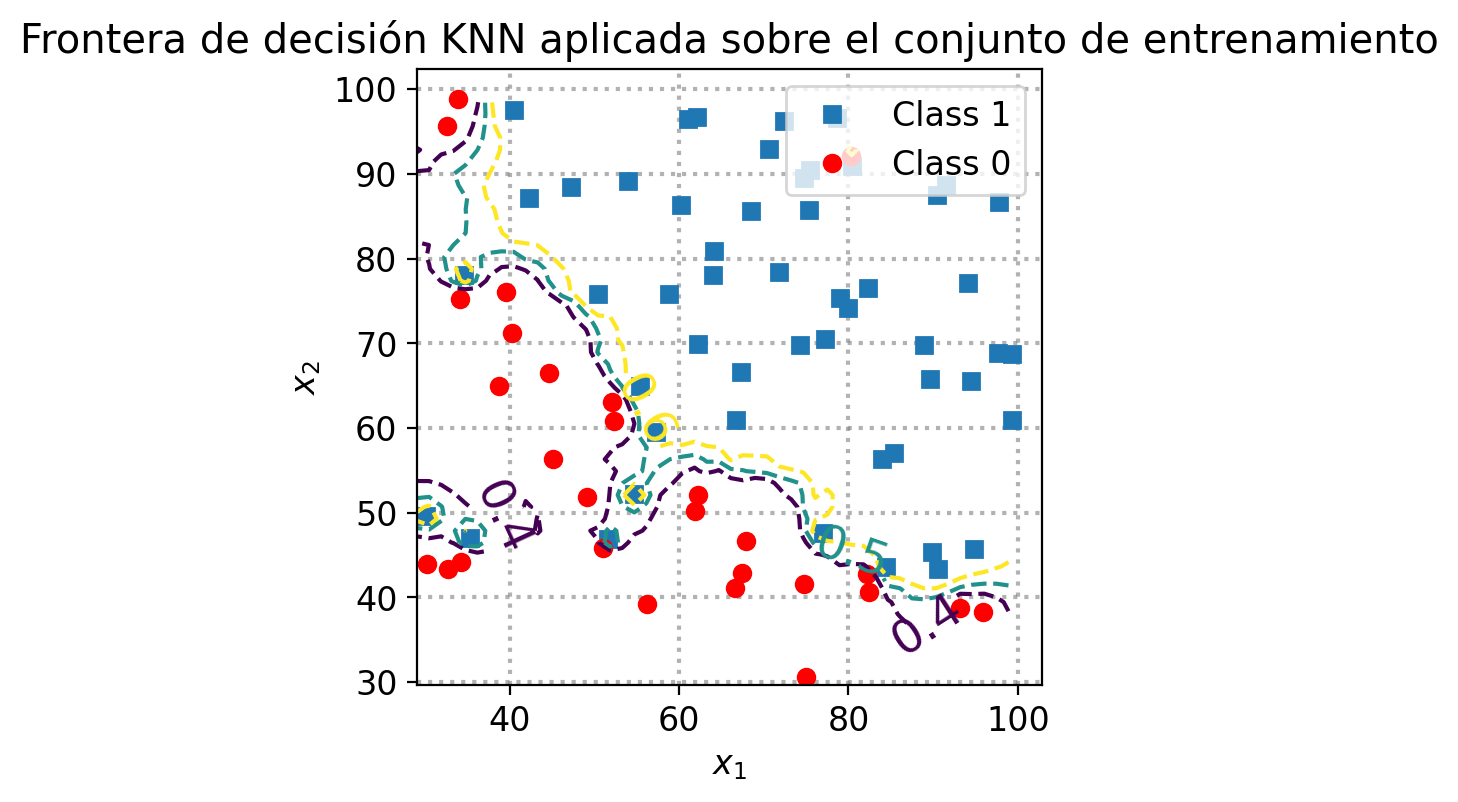

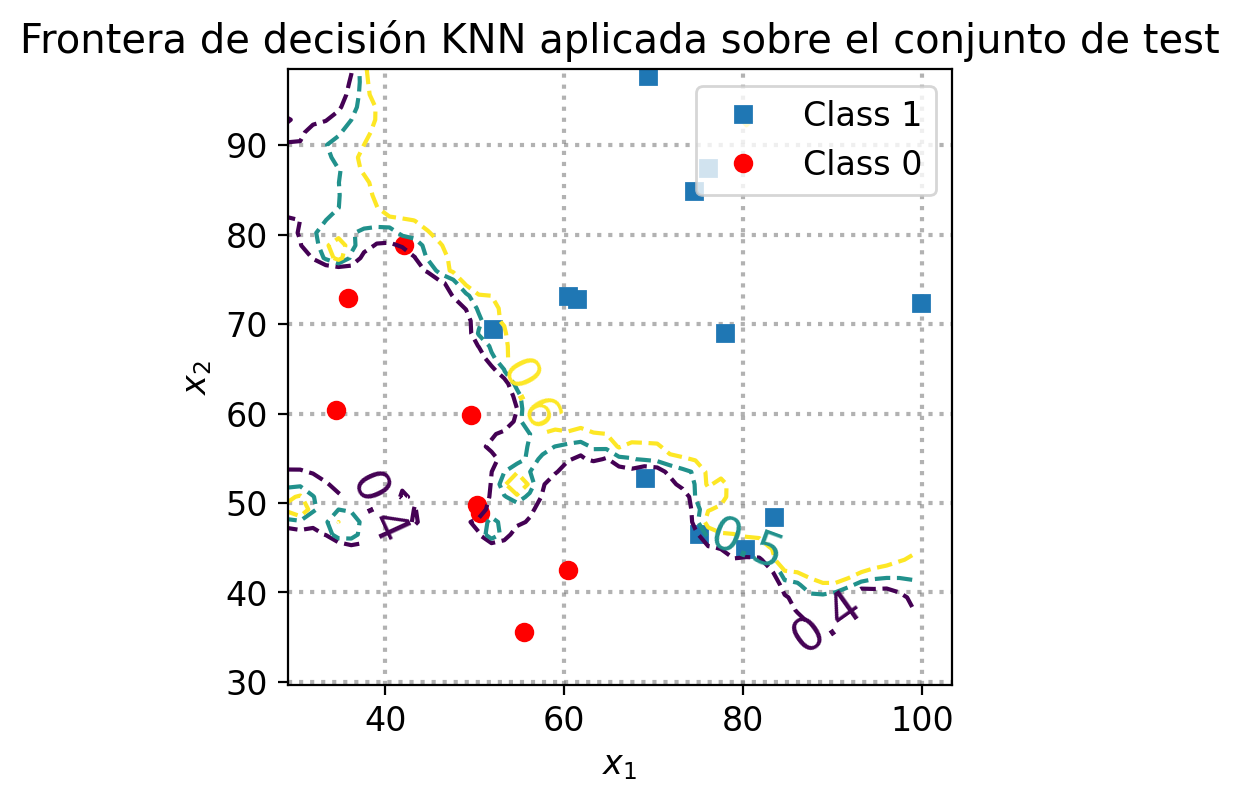

In [26]:
#Estimamos la probabilidad asociada a cada punto con el método .predic_proba
probs_knn=mi_knn.predict_proba(grid_norm)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

## Plot Training Data
plt.plot(X0_train[Y_train==1,0],X0_train[Y_train==1,1],'s',label="Class 1")
plt.plot(X0_train[Y_train==0,0],X0_train[Y_train==0,1],'ro',label="Class 0")
cs = ax.contour(x1,x2,np.reshape(probs_knn[:,1],np.shape(x1)),[0.4, 0.5, 0.6],linestyles='dashed')
ax.clabel(cs, inline=1, fontsize=17)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='upper right')
plt.title(r'Frontera de decisión KNN aplicada sobre el conjunto de entrenamiento')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

## Plot Training Data
plt.plot(X0_test[Y_test==1,0], X0_test[Y_test==1,1],'s',label="Class 1")
plt.plot(X0_test[Y_test==0,0], X0_test[Y_test==0,1],'ro',label="Class 0")
cs = ax.contour(x1,x2,np.reshape(probs_knn[:,1],np.shape(x1)),[0.4, 0.5, 0.6],linestyles='dashed')
ax.clabel(cs, inline=1, fontsize=17)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='upper right')
plt.title(r'Frontera de decisión KNN aplicada sobre el conjunto de test')
#major grid lines
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.show()

Podemos observar la **complejidad de las frontera de decisión** en el k-NN. Esto está asociado a la naturaleza **no paramétrica** del modelo. Viendo la frontera, que es capaz de tratar individualmente a algunos patrones, se puede comprender que generalice mal (accuracy de 100% en train, 85% en test)

**Entrenaremos ahora el modelo para la base de datos Spam**.

In [27]:
# K-NN con validación del número de vecinos
from sklearn import neighbors

# Parameters
K_max = 30
rango_K = np.arange(1, K_max+1)
nfold = 10
# Diccionario de parámetros
diccionario_parametros = [{'n_neighbors': rango_K,'weights':['uniform','distance']}]

# Validación cruzada con GridSearchCV
knn_spam_xval = GridSearchCV(estimator=neighbors.KNeighborsClassifier( ), param_grid=diccionario_parametros,cv=nfold)

# Entrenamiento
knn_spam_xval.fit(X_spam_train,Y_spam_train)

# Test
accuracy_train = knn_spam_xval.score(X_spam_train, Y_spam_train)
accuracy_test = knn_spam_xval.score(X_spam_test, Y_spam_test)

print("El mejor número de vecinos encontrado es k={0:d}".format(knn_spam_xval.best_params_['n_neighbors']))
print("Accuracy train {0:.2f}%. Accuracy test {1:.2f}%\n".format(accuracy_train*100, accuracy_test*100))

El mejor número de vecinos encontrado es k=15
Accuracy train 99.97%. Accuracy test 92.40%



Como vemos, tras realizar una **selección del hiperparámetro de número de vecinos**, el kNN es capaz de **mejorar ligeramente las prestaciones en test** del regresor logístico (Accuracy train 92.52%. Accuracy test 91.60%)

<a id='prestaciones'></a>
# 3 - Medida de prestaciones en clasificación binaria
---

- Hasta ahora hemos comparado los distintos clasificadores en base a una métrica, la fracción de etiquetas de train/test correctamente detectadas (*accuracy* en inglés).
$$$$
- Sin embargo, **no todos los errores son equiparables**:
    - En el caso anterior (detección de spam),  etiquetar un correo válido como spam es un error que podemos considerar mas grave que dejar de etiquetar un correo no deseado como spam.
    - En un problema de decisión de concesión de un préstamo, conceder un préstamo a una persona no solvente implica unas pérdidas mayores que dejar pasar a un cliente solvente ).
    
En este sentido, utilizar únicamente la fracción de etiquetas de train/test correctamente detectadas puede no ser la mejor idea. Vamos a definir una serie de métricas que proporcionan un espectro más completo para caracterizar un clasificador.

En un problema binario, cuando el clasificador realiza una estimación para un nuevo dato podemos diferenciar **cuatro** posibles eventos:

| | **Predicción** $D=1$ | **Predicción** $D=0$ |
| --- | --- | --- |
| **Etiqueta real** $Y=1$  | True Positive (TP) | False Negative or Missing (FN)|
| **Etiqueta real** $Y=0$  |  False Positive or False Alarm (FP)  | True Negative (TN) |

A partir de estos eventos medidos sobre un conjunto de datos clasificados podemos definir las siguientes métricas:

## 3.1 - Tasa de falsos positivos (o de falsa alarma)

FPR es la razón entre el número de falsos positivos y el número total de datos con etiqueta real $Y=0$ (la fracción de negativos que se nos han colado como positivos):

$$ FPR = \frac{\# FP}{ \# TN + \# FP }$$

## 3.2 - Especificidad o true negative rate

E o TNR es la razón entre el número de etiquetas negativas correctamente detectadas y el total de datos con etiqueta negativa $Y=0$ (qué fracción de negativos he conseguido detectar del total de negativos):

$$ E = \frac{\# TN}{\# TN + \# FP} = 1- FPR$$

## 3.3 - Tasa de falsos negativos (o de pérdidas)

FNR es la razón entre el número falsos negativos y el total de datos con etiqueta positiva $Y=1$ (la fracción de positivos que se nos han colado como negativos):

$$ FNR = \frac{\# FN}{ \# TP + \# FN }$$

## 3.4 - Sensibilidad o recall o true positive rate

R/S/TPR es la razón entre el número de etiquetas positivas correctamente detectadas y el total de datos con etiqueta positiva $Y=1$ (qué fracción de positivos he conseguido detectar del total de positivos):

$$ R = \frac{\# TP}{\# TP + \# FN} = 1- FNR$$


## 3.5 - Precisión

P es la razón entre el número de etiquetas positivas correctamente detectadas y el número total de datos **clasificados** con etiqueta positiva (qué fracción de los que yo he detectado como $Y=1$ realmente lo son):

$$ P = \frac{\# TP}{\# TP + \# FP}$$

La siguiente figura ayuda a entender las anteriores métricas [Wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall)

<img src="http://www.tsc.uc3m.es/~navia/figures/Precisionrecall.svg" width="40%">

La precisión (P) y el *recall* (R) suelen combinarse en una única métrica denominada **F-score** o **F1-score**:

$$F_{\text{score}} = 2 \frac{P\cdot R}{P+R}$$

Esta métrica varía entre 0 (peor caso) y 1 (mejor caso).

Vamos a calcular algunas de estas métricas para dos de los clasificadores entrenados anteriormente. Usaremos las siguientes funciones directamente proporcionadas por [sklearn](https://scikit-learn.org/stable/modules/model_evaluation.html):

- [Precision score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
- [Recall score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

In [29]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Métricas para el RL con regularización L2

precision_LR = precision_score(Y_spam_test, LR_spam.predict(X_spam_test))
recall_LR = recall_score(Y_spam_test, LR_spam.predict(X_spam_test))
F1_LR = f1_score(Y_spam_test, LR_spam.predict(X_spam_test))

print("\n Precision P = {0:.2f}".format(precision_LR))
print("\n Recall R = {0:.2f}".format(recall_LR))
print("\n F1 score, F1 = {0:.2f}".format(F1_LR))


 Precision P = 0.93

 Recall R = 0.86

 F1 score, F1 = 0.90


Y para k-NN ...

In [30]:
# Métricas para k-NN

print("\n Precision P = {0:.2f}".format(precision_score(Y_spam_test, knn_spam_xval.predict(X_spam_test))))
print("\n Recall R = {0:.2f}".format(recall_score(Y_spam_test, knn_spam_xval.predict(X_spam_test))))
print("\n F1 score, F1 = {0:.2f}".format(f1_score(Y_spam_test, knn_spam_xval.predict(X_spam_test))))


 Precision P = 0.94

 Recall R = 0.88

 F1 score, F1 = 0.91


# 4 - Variando el umbral de detección: curvas ROC y Precisión-Recall.

Hasta ahora, hemos supuesto que los distintos clasificadores deciden que la etiqueta asociada a un dato es aquella para la cual la probabilidad estimada es mayor que 0.5. Pero este valor, conocido como **umbral de decisión** es un hiperparámetro más que tenemos que fijar de acuerdo a nuestros requisitos de Precision, Recall, FPR o FNR.

Por ejemplo, si queremos maximizar el Recall en general tomaremos un umbral para detección de clase positiva por debajo de 0.5 (por ejemplo 0.2).

- Esto incrementará la tasa de datos detectados como positivos y será mas dificil que se nos haya escapado alguno.

- Pero también incrementará la tasa de falsos positivos y hará bajar la precisión. Esto es, las métricas típicamente están comprometidas unas con otras.

Para hacernos una **idea global del compromiso entre las distintas métricas** es habitual analizar la evolución del recall (R) frente a la tasa de falsos positivos (FPR) a medida que variamos el umbral de decisión.

- En la curva **ROC** (Receiver Operating Characteristic) mostramos la evolución de True Positive Rate frente a False Positive Rate.
- En la curva **Precisión-Recall** mostramos la evolución de la Precisión frente al Recall.

El comportamiento global se mide utilizando el **área bajo la curva** (**AUC**), que idealmente debe ser igual a 1.

Dibujemos estas curvas para el ejemplo spam anterior. Usando las funciones [roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) y [precision_recall_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html#sklearn.metrics.precision_recall_curve) de sklearn. Para el área bajo la curva usamos [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) y [average_precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html#sklearn.metrics.average_precision_score) respectivamente.

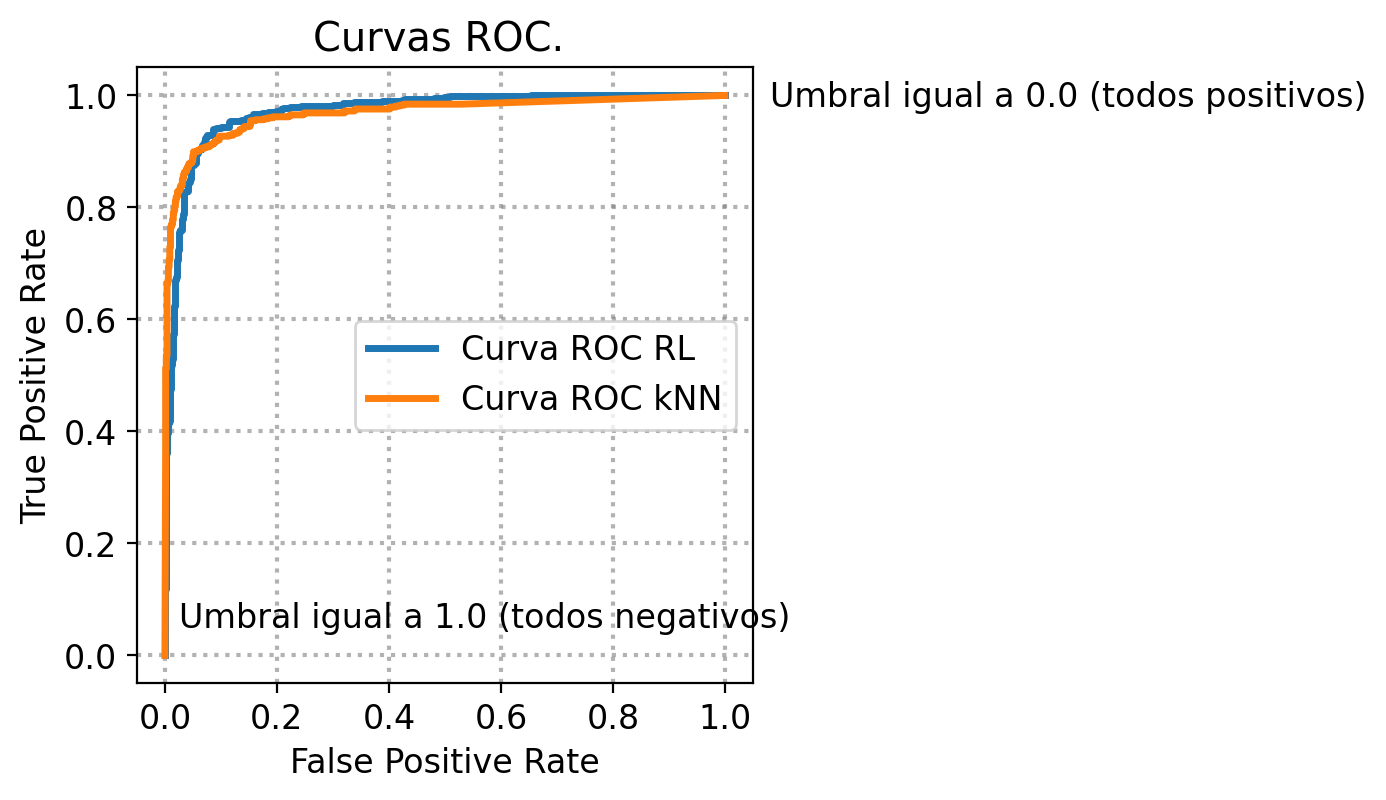


 Area bajo la curva ROC del modelo LR = 0.96

 Area bajo la curva ROC del modelo kNN = 0.96


In [31]:
from sklearn import metrics

# ROC curve RL

fpr, tpr, thresholds_fprtpr = metrics.roc_curve(Y_spam_test, LR_spam.predict_proba(X_spam_test)[:,1], pos_label=1)

# ROC curve k-NN

fpr2, tpr2, thresholds2_fprtpr = metrics.roc_curve(Y_spam_test, knn_spam_xval.predict_proba(X_spam_test)[:,1], pos_label=1)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(fpr,tpr,lw=2.5,label='Curva ROC RL')
plt.plot(fpr2,tpr2,lw=2.5,label='Curva ROC kNN')
plt.legend(loc=7)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC. ')
ax.text(1.08, 0.98, r'Umbral igual a 0.0 (todos positivos)')
ax.text(0.025, 0.05, r'Umbral igual a 1.0 (todos negativos)')
plt.show()

# Area bajo la curva ROC
area_roc_LR = metrics.average_precision_score(Y_spam_test, LR_spam.predict_proba(X_spam_test)[:,1])
print("\n Area bajo la curva ROC del modelo LR = {0:.2f}".format(area_roc_LR))
area_roc_knn = metrics.average_precision_score(Y_spam_test, knn_spam_xval.predict_proba(X_spam_test)[:,1])
print("\n Area bajo la curva ROC del modelo kNN = {0:.2f}".format(area_roc_knn))

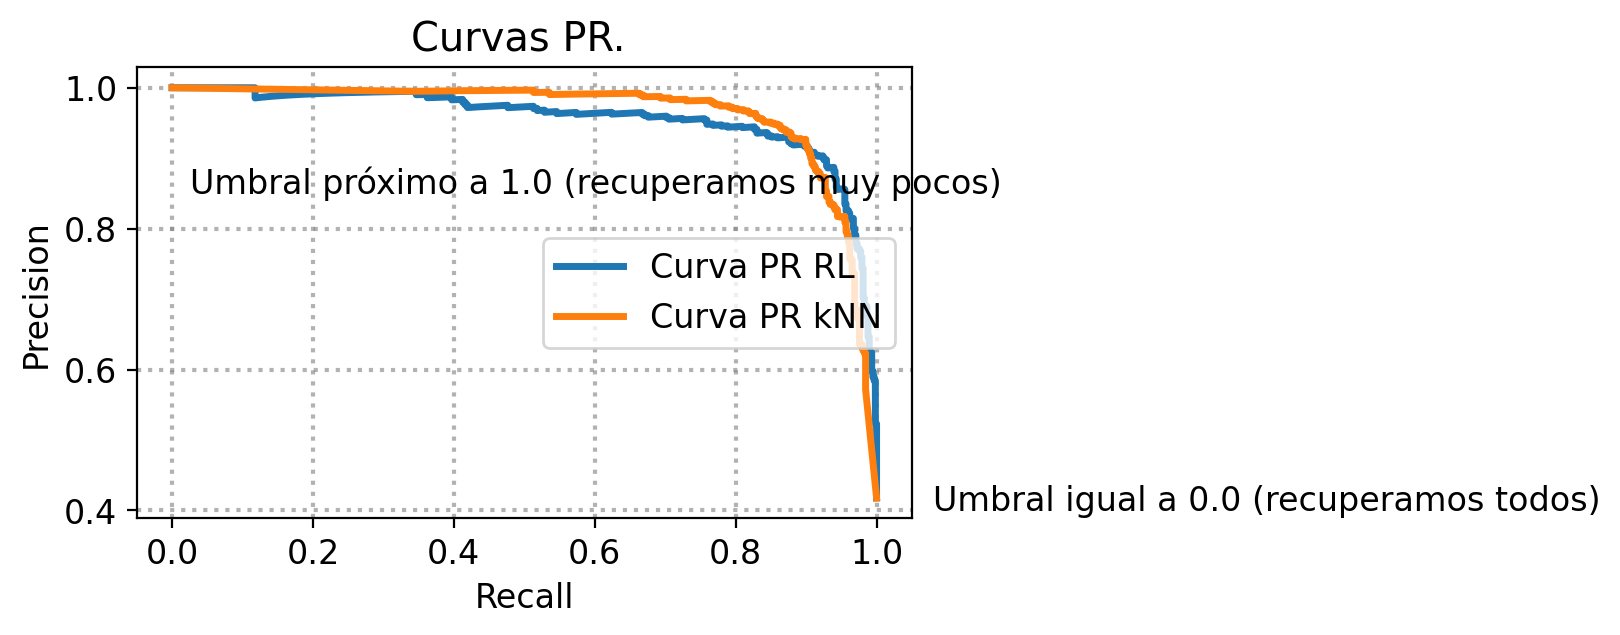


 Area bajo la curva ROC del modelo LR = 0.97

 Area bajo la curva ROC del modelo kNN = 0.97


In [32]:
from sklearn import metrics

# PR curve RL

precision, recall, thresholds_PR = metrics.precision_recall_curve(Y_spam_test, LR_spam.predict_proba(X_spam_test)[:,1], pos_label=1)

# PR curve k-NN

precision2, recall2, thresholds2_PR = metrics.precision_recall_curve(Y_spam_test, knn_spam_xval.predict_proba(X_spam_test)[:,1], pos_label=1)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(recall,precision,lw=2.5,label='Curva PR RL')
plt.plot(recall2,precision2,lw=2.5,label='Curva PR kNN')
plt.legend(loc=7)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas PR. ')
ax.text(1.08, 0.4, r'Umbral igual a 0.0 (recuperamos todos)')
ax.text(0.025, 0.85, r'Umbral próximo a 1.0 (recuperamos muy pocos)')
plt.show()

# Area bajo la curva PR
area_roc_LR = metrics.roc_auc_score(Y_spam_test, LR_spam.predict_proba(X_spam_test)[:,1])
print("\n Area bajo la curva ROC del modelo LR = {0:.2f}".format(area_roc_LR))
area_roc_kNN = metrics.roc_auc_score(Y_spam_test, knn_spam_xval.predict_proba(X_spam_test)[:,1])
print("\n Area bajo la curva ROC del modelo kNN = {0:.2f}".format(area_roc_kNN))


Comprobamos de nuevo que **no hay grandes diferencias entre RL y k-NN**. **A igualdad de prestaciones, deberíamos tomar el modelo más sencillo** ("**Occam's razor**").

## Ejercicio

Representar Los valores de Precisión, Recall, True Positive Rate y False Positive Rate con respecto al valor del umbral para el caso de regresión logística. Interprete los resultados y obtenga los umbrales para que cada una de estas medidas tome un valor de 0.8.



In [ ]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(<INSERT CODE HERE>,<INSERT CODE HERE>,lw=2.5,label='Curva FPR RL')
plt.plot(<INSERT CODE HERE>,<INSERT CODE HERE>,'k', lw=2.5,label='Curva TPR RL')
plt.plot(<INSERT CODE HERE>,<INSERT CODE HERE>,lw=2.5,label='Curva Precisión RL')
plt.plot(<INSERT CODE HERE>,<INSERT CODE HERE>,'--',lw=2.5, label='Curva Recall RL')

plt.legend(loc=7)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('Umbral de decisión')
plt.ylabel('Medida')
plt.title('Evolución de las diferentes medidas según el umbral de decisión')

target = 0.8

pos = <INSERT CODE HERE>
th_fpr = <INSERT CODE HERE>
print("\nEl valor del umbral para que FPR se acerque a {} sería de {}, el valor obtenido de FPR sería {}".format(target, th_fpr, fpr[pos]))

pos = <INSERT CODE HERE>
th_tpr = <INSERT CODE HERE>
print("\nEl valor del umbral para que TPR se acerque a {} sería de {}, el valor obtenido de TPR sería {}".format(target, th_tpr, tpr[pos]))

pos = <INSERT CODE HERE>
th_precision = <INSERT CODE HERE>
print("\nEl valor del umbral para que PRECISION se acerque a {} sería de {}, el valor obtenido de PRECISION sería {}".format(target, th_precision, precision[pos]))

pos = <INSERT CODE HERE>
th_recall = <INSERT CODE HERE>
print("\nEl valor del umbral para que RECALL se acerque a {} sería de {}, el valor obtenido de RECALL sería {}".format(target, th_recall, recall[pos]))



## Solución


El valor del umbral para que FPR se acerque a 0.8 sería de 0.0003546656846372679, el valor obtenido de FPR sería 0.8283582089552238

El valor del umbral para que TPR se acerque a 0.8 sería de 0.6218685511224307, el valor obtenido de TPR sería 0.8093587521663779

El valor del umbral para que PRECISION se acerque a 0.8 sería de 0.21251202546504602, el valor obtenido de PRECISION sería 0.7997138769670958

El valor del umbral para que RECALL se acerque a 0.8 sería de 0.6370377389031542, el valor obtenido de RECALL sería 0.8006932409012132


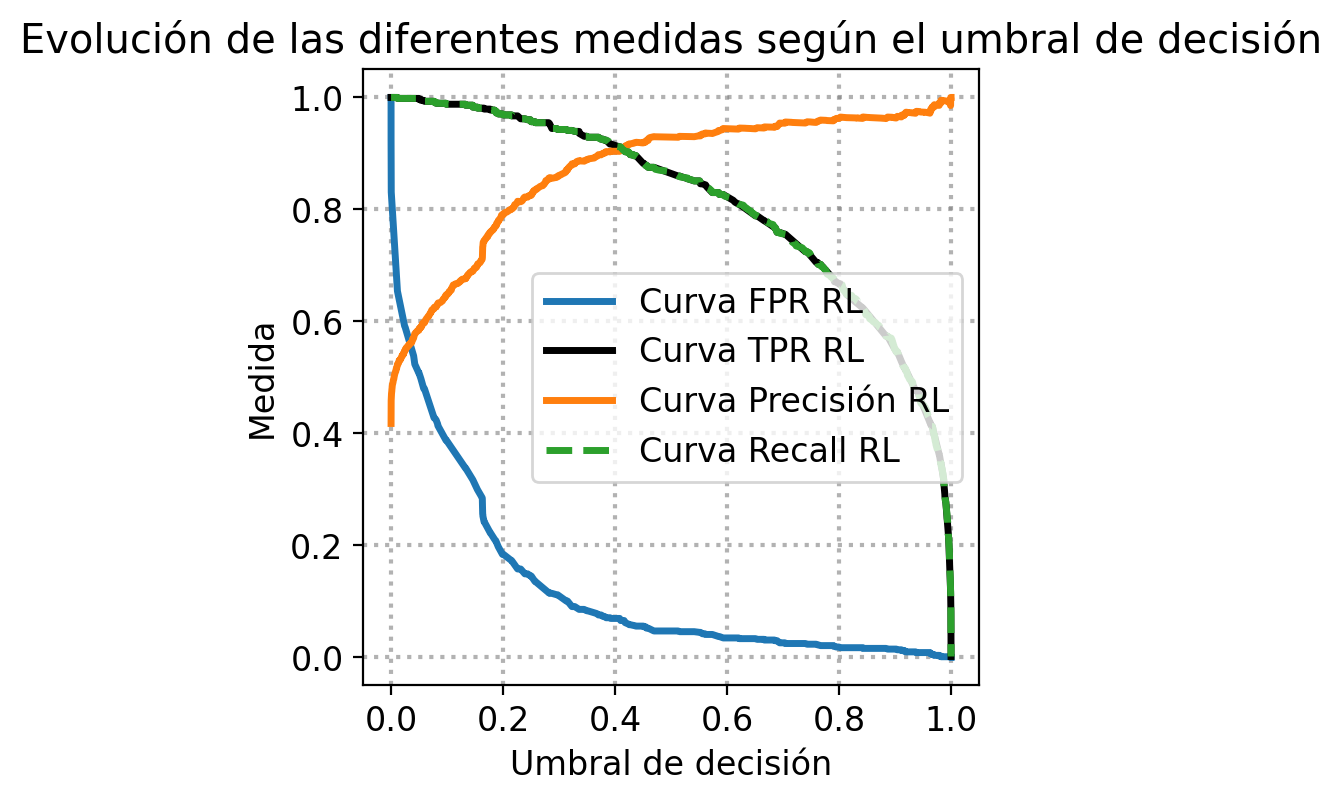

In [34]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(thresholds_fprtpr,fpr,lw=2.5,label='Curva FPR RL')
plt.plot(thresholds_fprtpr,tpr,'k', lw=2.5,label='Curva TPR RL')
plt.plot(thresholds_PR,precision[0:len(thresholds_PR)],lw=2.5,label='Curva Precisión RL')
plt.plot(thresholds_PR,recall[0:len(thresholds_PR)],'--',lw=2.5, label='Curva Recall RL')

plt.legend(loc=7)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('Umbral de decisión')
plt.ylabel('Medida')
plt.title('Evolución de las diferentes medidas según el umbral de decisión')

target = 0.8

pos = np.argmin(abs(fpr-target))
th_fpr = thresholds_fprtpr[pos]
print("\nEl valor del umbral para que FPR se acerque a {} sería de {}, el valor obtenido de FPR sería {}".format(target, th_fpr, fpr[pos]))

pos = np.argmin(abs(tpr-target))
th_tpr = thresholds_fprtpr[pos]
print("\nEl valor del umbral para que TPR se acerque a {} sería de {}, el valor obtenido de TPR sería {}".format(target, th_tpr, tpr[pos]))

pos = np.argmin(abs(precision-target))
th_precision = thresholds_PR[pos]
print("\nEl valor del umbral para que PRECISION se acerque a {} sería de {}, el valor obtenido de PRECISION sería {}".format(target, th_precision, precision[pos]))

pos = np.argmin(abs(recall-target))
th_recall = thresholds_PR[pos]
print("\nEl valor del umbral para que RECALL se acerque a {} sería de {}, el valor obtenido de RECALL sería {}".format(target, th_recall, recall[pos]))

Como vemos, **no es posible elegir un único umbral que nos proporcione los valores deseados simultaneamente para cada una de las métricas**. Observamos también que las curvas de recall y true positive rate coinciden, como se indicaba en sus definiciones.

## Ejercicio de ampliación (opcional):

Defina una función que permita parametrizar cualquier texto al formato de entrada requerido para utilizar estos dos clasificadores. Evalúe los resultados al aplicar el modelo de Regresión Logística entrenado anteriormente, al utilizar como entrada los siguientes texto1 y texto2.

In [35]:
texto1 = "YOUR MAILBOX IS FULL! Your email messages are now queued up and pending delivery because your email has not been validated. You are required to verify your Email: navia@tsc.uc3m.es to restore normal email delivery. To Fix this issue Verify Email Now and save $$$!!! Action Required! Pending High Priority. Disclaimer: This email and its content are confidential and intended solely for the use of the addressee.This message was sent from an unmonitored e-mail address please do not reply to this message Privacy|TermSecured by Proofpoint Encryption. [Copyright © 2009-2024 Proofpoint. Inc. All rights reserved.]"

texto2 = "Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation.Python is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly procedural), object-oriented and functional programming. It is often described as a batteries included language (due to its comprehensive standard library)."

print("Estos son los dos textos a classificar como spam/no spam:\n")
print(texto1)
print("\n")
print(texto2)

Estos son los dos textos a classificar como spam/no spam:

YOUR MAILBOX IS FULL! Your email messages are now queued up and pending delivery because your email has not been validated. You are required to verify your Email: navia@tsc.uc3m.es to restore normal email delivery. To Fix this issue Verify Email Now and save $$$!!! Action Required! Pending High Priority. Disclaimer: This email and its content are confidential and intended solely for the use of the addressee.This message was sent from an unmonitored e-mail address please do not reply to this message Privacy|TermSecured by Proofpoint Encryption. [Copyright © 2009-2024 Proofpoint. Inc. All rights reserved.]


Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation.Python is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly procedural), object-oriented and funct

In [ ]:
# 48 variables reales continuas en el intervalo [0,100] *word_freq_WORD*: frecuencia de aparición de la palabra *WORD* en el correo (en porcentaje)
# 6 variables reales continuas en el intervalo [0,100] *char_freq_CHAR*: frecuencia de aparición del caracter *CHAR* en el correo (porcentaje)
# 1 variable real continua: longitud promedio de secuencias de caracteres en mayúscula ininterrumpidos
# 1 variable entera continua: longitud de la secuencia de mayúsculas ininterrumpida más larga
# 1 variable entera continua: número total de mayúsculas en el correo

# longitud promedio de cadenas en mayúsculas
tokens1_sin_normalizar = <INSERT CODE HERE>
tokens2_sin_normalizar = <INSERT CODE HERE>
tokens1_normalizados = <INSERT CODE HERE>
tokens2_normalizados = <INSERT CODE HERE>

conteos_palabras1 = <INSERT CODE HERE>
conteos_palabras2 = <çINSERT CODE HERE>
conteos_caracteres1 = <INSERT CODE HERE>
conteos_caracteres2 = <INSERT CODE HERE>

# Long_may
prom_long_mayusculas1, max_long_mayusculas1, numero_total_mayusculas1 = <INSERT CODE HERE>
prom_long_mayusculas2, max_long_mayusculas2, numero_total_mayusculas2 = <INSERT CODE HERE>

x1_no_escalado = <INSERT CODE HERE>
x2_no_escalado = <INSERT CODE HERE>

x1_escalado = <INSERT CODE HERE>
x2_escalado = <INSERT CODE HERE>

p1 = <INSERT CODE HERE>
p2 = <INSERT CODE HERE>

print("\nLa probabilidad de que el texto 1 es spam es p = {}".format(p1))

print("\nLa probabilidad de que el texto 2 es spam es p = {}".format(p2))

## Solución:

In [36]:
# 48 variables reales continuas en el intervalo [0,100] *word_freq_WORD*: frecuencia de aparición de la palabra *WORD* en el correo (en porcentaje)
# 6 variables reales continuas en el intervalo [0,100] *char_freq_CHAR*: frecuencia de aparición del caracter *CHAR* en el correo (porcentaje)
# 1 variable real continua: longitud promedio de secuencias de caracteres en mayúscula ininterrumpidos
# 1 variable entera continua: longitud de la secuencia de mayúsculas ininterrumpida más larga
# 1 variable entera continua: número total de mayúsculas en el correo

# longitud promedio de cadenas en mayúsculas
import spacy
nlp = spacy.load("en_core_web_sm")
texto1_spacy = nlp(texto1)
texto2_spacy = nlp(texto2)


In [37]:
tokens1_sin_normalizar = [token.text for token in texto1_spacy]
tokens2_sin_normalizar = [token.text for token in texto2_spacy]

tokens1_normalizados = [w.lemma_.lower() for w in texto1_spacy if not w.is_stop
                  and not w.is_punct and (w.is_alpha or w.is_digit)]
tokens2_normalizados = [w.lemma_.lower() for w in texto2_spacy if not w.is_stop
                  and not w.is_punct and (w.is_alpha or w.is_digit)]

In [38]:
conteos_palabras1 = np.zeros((len(palabras), 1))
conteos_palabras2 = np.zeros((len(palabras), 1))
for k in range(len(palabras)):
    conteos_palabras1[k] = tokens1_normalizados.count(palabras[k])
    conteos_palabras2[k] = tokens2_normalizados.count(palabras[k])

conteos_palabras1 = conteos_palabras1 / len(tokens1_normalizados) * 100
conteos_palabras2 = conteos_palabras2 / len(tokens2_normalizados) * 100

conteos_caracteres1 = np.zeros((len(caracteres), 1))
conteos_caracteres2 = np.zeros((len(caracteres), 1))
for k in range(len(caracteres)):
    conteos_caracteres1[k] = texto1.count(caracteres[k])
    conteos_caracteres2[k] = texto2.count(caracteres[k])

conteos_caracteres1 = conteos_caracteres1 / len(tokens1_sin_normalizar) * 100
conteos_caracteres2 = conteos_caracteres2 / len(tokens2_sin_normalizar) * 100

In [39]:
import re

def long_mayusculas(text):
    seq_may = re.findall(r'[A-Z]+', text)

    if not seq_may:
        return 0
    else:
      promedio = sum(len(seq) for seq in seq_may) / len(seq_may)
      maximo = np.max([len(seq) for seq in seq_may])
      numero_total_mayusculas = sum(len(seq) for seq in seq_may)
      return promedio, maximo, numero_total_mayusculas

# Long_mayusculas
prom_long_mayusculas1, max_long_mayusculas1, numero_total_mayusculas1 = long_mayusculas(texto1)
prom_long_mayusculas2, max_long_mayusculas2, numero_total_mayusculas2 = long_mayusculas(texto2)

In [40]:
# Construyendo los vectores de entrada
x1_no_escalado = np.vstack([conteos_palabras1, conteos_caracteres1, np.array([prom_long_mayusculas1, max_long_mayusculas1, numero_total_mayusculas1]).reshape(3, 1)]).T
x2_no_escalado = np.vstack([conteos_palabras2, conteos_caracteres2, np.array([prom_long_mayusculas2, max_long_mayusculas2, numero_total_mayusculas2]).reshape(3, 1)]).T


In [41]:
# Reescalando la entrada
x1_escalado = transformer_spam.transform(x1_no_escalado)
x2_escalado = transformer_spam.transform(x2_no_escalado)

In [42]:
# Obtenemos las predicciones
p1 = LR_spam.predict_proba(x1_escalado)[0][1]
p2 = LR_spam.predict_proba(x2_escalado)[0][1]

print("\nLa probabilidad de que el texto 1 es spam es p = {}".format(p1))

print("\nLa probabilidad de que el texto 2 es spam es p = {}".format(p2))



La probabilidad de que el texto 1 es spam es p = 0.9999969207116245

La probabilidad de que el texto 2 es spam es p = 0.09696682716419201


## Ejercicio de ampliación 2:

La observación de los pesos de un modelo no es el mejor de los métodos para **identificar las variables más relevantes**, ya que habitualmente existe correlación entre las entradas. Proponemos aquí identificar los términos más relevantes para el problema de decisión resuelto anteriormente (detección de spam) usando el **método SHAP (SHapley Additive exPlanations)**, el método de referencia para la **Inteligencia Artificial Explicable (XAI)**.

- **Instalar e importar la librería de python "shap"**
- Utilizar el modelo de regresión lineal y la opción de shap **LinearExplainer**
- Utilizar los **shap_values** obtenidos para ordenar por importancia las características que influyen positiva o negativamente en la clasificación.